In [1]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

from ucimlrepo import fetch_ucirepo

steel_plates_faults = fetch_ucirepo(id=198)

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

X = steel_plates_faults.data.features
y = steel_plates_faults.data.targets

y = np.argmax(y.values, axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.from_numpy(X_train_scaled).float().to(device)
X_test_tensor = torch.from_numpy(X_test_scaled).float().to(device)
y_train_tensor = torch.from_numpy(y_train).long().to(device)
y_test_tensor = torch.from_numpy(y_test).long().to(device)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


class UniversalSteelNet(nn.Module):
    def __init__(self, hidden_layers):
        super(UniversalSteelNet, self).__init__()
        layers = []
        input_dim = 27
        
        # Dynamiczne budowanie warstw ukrytych
        for h_dim in hidden_layers:
            layers.append(nn.Linear(input_dim, h_dim))
            layers.append(nn.ReLU())
            input_dim = h_dim
        
        # Warstwa wyjściowa (7 klas)
        layers.append(nn.Linear(input_dim, 7))
        
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


In [2]:
# --- KONFIGURACJA SIATKI ---
# k1_grid = [2, 4, 8, 16, 25, 32, 50, 64, 100, 128, 256]
# k2_grid = [2, 4, 8, 16, 25, 32, 50, 64, 100, 128, 256]
k1_grid = [16, 32, 64, 128, 256]
k2_grid = [16, 32, 64, 128, 256]
num_repeats = 3
results_3d = np.zeros((len(k1_grid), len(k2_grid)))

print("Generowanie mapy 3D dla K1 i K2...")

for i, k1 in enumerate(k1_grid):
    for j, k2 in enumerate(k2_grid):
        run_accs = []
        for r in range(num_repeats):
            # Używamy modelu 2-warstwowego jako bazy
            model = UniversalSteelNet([k1, k2]).to(device)
            optimizer = optim.Adam(model.parameters(), lr=0.001)
            criterion = nn.CrossEntropyLoss()
            
            for epoch in range(20):
                model.train()
                for x_batch, y_batch in train_loader:
                    optimizer.zero_grad()
                    loss = criterion(model(x_batch), y_batch)
                    loss.backward()
                    optimizer.step()
            
            model.eval()
            with torch.no_grad():
                acc = (model(X_test_tensor).argmax(1) == y_test_tensor).float().mean().item() * 100
                run_accs.append(acc)
        
        results_3d[i, j] = np.mean(run_accs)
        print(f"K1={k1}, K2={k2} | Średnia: {results_3d[i, j]:.2f}%")

Generowanie mapy 3D dla K1 i K2...
K1=16, K2=16 | Średnia: 70.52%
K1=16, K2=32 | Średnia: 73.18%
K1=16, K2=64 | Średnia: 73.44%
K1=16, K2=128 | Średnia: 73.95%
K1=16, K2=256 | Średnia: 74.29%
K1=32, K2=16 | Średnia: 73.35%
K1=32, K2=32 | Średnia: 73.52%
K1=32, K2=64 | Średnia: 74.21%
K1=32, K2=128 | Średnia: 74.46%
K1=32, K2=256 | Średnia: 75.32%
K1=64, K2=16 | Średnia: 73.78%
K1=64, K2=32 | Średnia: 74.89%
K1=64, K2=64 | Średnia: 74.46%
K1=64, K2=128 | Średnia: 74.04%
K1=64, K2=256 | Średnia: 75.15%
K1=128, K2=16 | Średnia: 74.98%
K1=128, K2=32 | Średnia: 74.21%
K1=128, K2=64 | Średnia: 74.81%
K1=128, K2=128 | Średnia: 74.72%
K1=128, K2=256 | Średnia: 76.01%
K1=256, K2=16 | Średnia: 75.15%
K1=256, K2=32 | Średnia: 74.55%
K1=256, K2=64 | Średnia: 75.41%
K1=256, K2=128 | Średnia: 75.06%
K1=256, K2=256 | Średnia: 76.26%


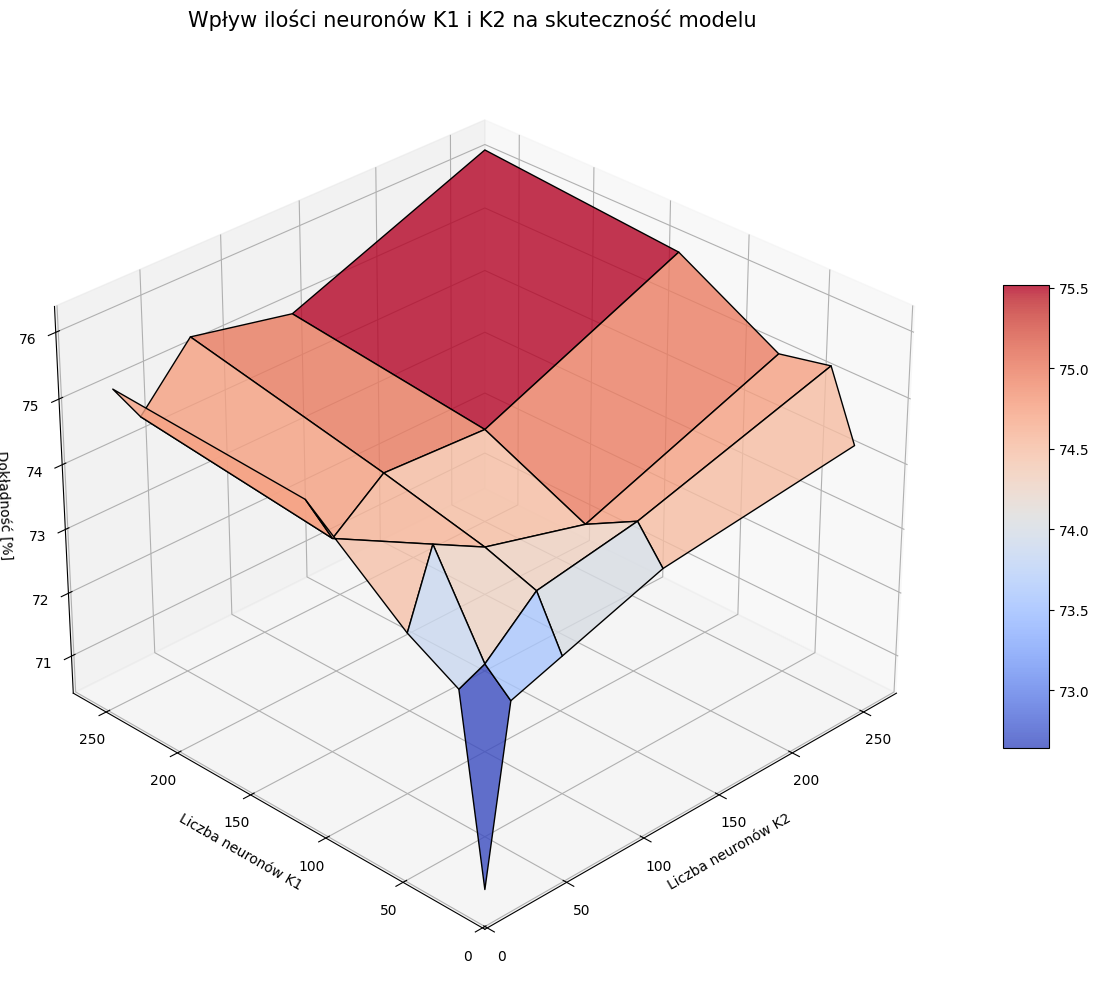

In [3]:
# --- GENEROWANIE WYKRESU 3D ---
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

X, Y = np.meshgrid(k2_grid, k1_grid)
Z = results_3d

# Tworzenie powierzchni z kolorami
surf = ax.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='black', alpha=0.8)

ax.set_title('Wpływ ilości neuronów K1 i K2 na skuteczność modelu', fontsize=15, pad=20)
ax.set_xlabel('Liczba neuronów K2')
ax.set_ylabel('Liczba neuronów K1')
ax.set_zlabel('Dokładność [%]')

# Dodanie paska kolorów
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)

# Ustawienie kąta widzenia, żeby dobrze było widać szczyt
ax.view_init(elev=30, azim=225)

plt.tight_layout()
plt.show()

In [4]:
np.argmax(results_3d)

np.int64(24)